# Test LLM Workflow (ReAct Agent with Tool Calling + SQL Validation)

**Objective:** Verify the pipeline uses `workflow.py`, `reasoner.py`, `vectorRag.py`, and `SQLvalidator.py` with Trinity's tool calling.

**Pipeline (ReAct agent):**
- `retrieval.graph.node.workflow` → compiled ReAct graph
- `retrieval.graph.node.reasoner` → LLM decides when to call tools
- `retrieval.graph.tool.vectorRag` → `get_schema_context` tool (ChromaDB RAG for table/column names)
- `retrieval.graph.tool.SQLvalidator` → `validate_sql_query` tool (safety + performance checks via DuckDB)
- **Requires:** Trinity (`arcee-ai/trinity-large-preview:free`) or another tool-capable model

**Expected flow per query:**
1. LLM calls `get_schema_context` → retrieves relevant schema from vector DB
2. LLM generates DuckDB SQL using the schema
3. LLM calls `validate_sql_query` → checks safety/performance
4. If issues found, LLM fixes and re-validates; otherwise returns final SQL

In [27]:
import sys
import importlib
sys.path.insert(0, "..")

from dotenv import load_dotenv
load_dotenv("../.env")

# Force reload of modules (use after editing any source file)
import retrieval.llm as llm_mod
import retrieval.graph.tool.SQLvalidator as sql_val_mod
import retrieval.graph.node.reasoner as reasoner_mod
import retrieval.graph.node.workflow as workflow_mod

importlib.reload(llm_mod)        # reload llm first — others depend on it
importlib.reload(sql_val_mod)    # reload validator before reasoner binds tools
importlib.reload(reasoner_mod)
importlib.reload(workflow_mod)

# Import the compiled graph and both tools
from retrieval.graph.node.workflow import react_graph
from retrieval.graph.tool.vectorRag import get_schema_context
from retrieval.graph.tool.SQLvalidator import validate_sql_query

# Sanity check
assert "reasoner" in react_graph.nodes and "tools" in react_graph.nodes
print("✓ Graph loaded: workflow.py / reasoner.py / vectorRag.py / SQLvalidator.py")

✓ Graph loaded: workflow.py / reasoner.py / vectorRag.py / SQLvalidator.py


## 1. Graph Display

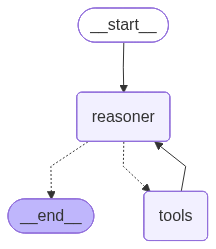

In [28]:
# PNG visualization (requires graphviz or pyppeteer)
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

## 2. Run with Example Query

Query: "What are all the unique drugs used for cancer treatment". Watch the stream to see each step as it executes.

In [29]:
query = "What are all the unique drugs used for cancer treatment"

initial_state = {
    "query": query,
    "final_answer": "",
    "messages": [],
}

## 3. Run Workflow

Invoke the ReAct agent: reasoner → (tool call) → tools → reasoner → SQL.

In [30]:
# Run the workflow (reasoner → tools → reasoner)
result = react_graph.invoke(initial_state)

# Print execution trace
for i, msg in enumerate(result["messages"]):
    msg_type = type(msg).__name__
    print(f"\n[Message {i}] {msg_type}")
    if msg_type == "AIMessage" and getattr(msg, "tool_calls", None):
        print(f"  Tool calls: {[tc['name'] for tc in msg.tool_calls]}")
    if hasattr(msg, "content") and msg.content:
        print(f"  Content: {str(msg.content)[:400]}...")


[Message 0] AIMessage
  Tool calls: ['get_schema_context']
  Content: I'll help you find all the unique drugs used for cancer treatment. Let me first retrieve the relevant schema to understand the available tables and columns.
...

[Message 1] ToolMessage
  Content: TABLE: drug_exposure_cancerdrugs
COLUMN: drug_concept_id
  Data Element: Concept ID for Drug Prescribed
  Description: Concept id for individual drugs prescribed. Concept ids are mapped using item codes.
  User Guide: The DRUG_CONCEPT_ID field is recommended for primary use in analyses, and must be used for network studies. This is the standard concept mapped from the source concept id which repre...

[Message 2] AIMessage
  Tool calls: ['validate_sql_query']
  Content: Now I'll create a SQL query to find all unique drugs used for cancer treatment. Based on the schema, I can see there's a table called `drug_exposure_cancerdrugs` with a column `drug_source_value` that contains the drug names.

Let me validate this SQL query

Final Test

In [31]:
# Extract final SQL (last AIMessage without pending tool calls)
final_ai = [
    m for m in result["messages"]
    if hasattr(m, "content") and m.content and not getattr(m, "tool_calls", None)
][-1]
result_sql = final_ai.content

print("Final SQL/Answer:")
print(result_sql)

# --- Assertions ---
def tool_was_called(messages, tool_name):
    return any(
        getattr(m, "tool_calls", None) and
        any(tc.get("name") == tool_name for tc in m.tool_calls)
        for m in messages
    )

assert tool_was_called(result["messages"], "get_schema_context"), \
    "FAIL: get_schema_context was not called"
assert tool_was_called(result["messages"], "validate_sql_query"), \
    "FAIL: validate_sql_query was not called — LLM did not validate the SQL"
assert result_sql and len(result_sql.strip()) > 0, "FAIL: No SQL generated"

print("\n✓ TEST PASSED: LLM used get_schema_context, generated SQL, and validated it with validate_sql_query")

Final SQL/Answer:
Here are all the unique drugs used for cancer treatment found in the database:

1. Fluorouracil 5,000mg/100mL Inj
2. TRIFLURIDINE 20MG TAB (SAMPLE);TIPIRACIL 9.42MG(LONSURF 20)
3. hydroxyCARBAMIDE/hydroxyUREA 500MG CAP (HYDRINE)
4. PANItumumab 100MG/5ML INJ (VECTIBIX)
5. DABRAFENIB 75MG CAP (TAFINLAR)
6. FLUOROURACIL 1000MG/20ML INJ
7. Bevacizumab [AVASTIN] 100mg/4mL Inj
8. Bevacizumab [AVASTIN] 400mg/16mL Inj
9. TRASTUZUMAB 440MG INJ (OGIVRI)
10. Panitumumab [VECTIBIX] 100mg/5mL Inj - NP
11. Leuprorelin Acetate [LUCRIN DEPOT] 11.25mg Inj
12. HydroxyCARBAmide [Hydroxyurea] 500mg Cap
13. TRIFLURIDINE 15MG, TIPIRACIL TAB (LONSURF)
14. Oxaliplatin 200mg/40mL Inj
15. Oxaliplatin 100mg/20mL Inj
16. LAPATinib 250MG TAB (TYKERB)
17. Irinotecan HCl 100mg/5mL Inj
18. PEMBROLIZUMAB 100MG/4ML INJ (KEYTRUDA) -SAMPLE
19. MEGESTROL ACETATE 160MG TAB
20. RAMUCIRUMAB 500MG INJ (CYRAMZA)
21. RUXOLITINIB 5MG TAB (JAKAVI)-TRIAL
22. Ipilimumab 50mg/10mL Inj [YERVOY] - NP
23. CAPECITABINE

---
## 4. Sample Query Tests

Run multiple natural-language prompts through the full pipeline and inspect the tool-call trace for each. Each run should show:
- `get_schema_context` called to fetch relevant columns/tables from the vector DB
- `validate_sql_query` called to safety/performance-check the generated SQL

In [32]:
def run_query(prompt: str) -> dict:
    """Run a natural-language prompt through the ReAct graph and print the tool trace."""
    print(f"\n{'='*60}")
    print(f"QUERY: {prompt}")
    print('='*60)

    state = {"query": prompt, "final_answer": "", "messages": []}
    result = react_graph.invoke(state)

    for i, msg in enumerate(result["messages"]):
        msg_type = type(msg).__name__
        if msg_type == "AIMessage" and getattr(msg, "tool_calls", None):
            tools_called = [tc["name"] for tc in msg.tool_calls]
            print(f"  [msg {i}] AIMessage → tool calls: {tools_called}")
        elif msg_type == "ToolMessage":
            # Show which tool responded and a short snippet
            tool_name = getattr(msg, "name", "unknown")
            snippet = str(msg.content)[:120].replace("\n", " ")
            print(f"  [msg {i}] ToolMessage  ({tool_name}): {snippet}...")
        elif msg_type == "AIMessage" and getattr(msg, "content", None):
            print(f"  [msg {i}] AIMessage (final):")
            print(f"    {msg.content.strip()}")

    # Summary assertions
    schema_ok = tool_was_called(result["messages"], "get_schema_context")
    valid_ok  = tool_was_called(result["messages"], "validate_sql_query")
    final_msg = [
        m for m in result["messages"]
        if hasattr(m, "content") and m.content and not getattr(m, "tool_calls", None)
    ]
    sql_ok = bool(final_msg)

    status = "✓ PASS" if (schema_ok and valid_ok and sql_ok) else "✗ FAIL"
    print(f"\n  get_schema_context called : {schema_ok}")
    print(f"  validate_sql_query called : {valid_ok}")
    print(f"  Final SQL produced        : {sql_ok}")
    print(f"  {status}")
    return result

### Query 1 — Simple aggregate: count patients by gender

In [33]:
result1 = run_query("How many patients are there for each gender?")


QUERY: How many patients are there for each gender?
  [msg 0] AIMessage → tool calls: ['get_schema_context']
  [msg 1] ToolMessage  (get_schema_context): TABLE: person COLUMN: gender_source_value   Data Element: Gender   Description: Source value of patient's gender   User ...
  [msg 2] AIMessage → tool calls: ['validate_sql_query']
  [msg 3] ToolMessage  (validate_sql_query): SQL is valid. Tables referenced: ['person']. Proceed to get_data....
  [msg 4] AIMessage → tool calls: ['get_data']
  [msg 5] ToolMessage  (get_data): [   {     "gender_source_value":"female",     "patient_count":49   },   {     "gender_source_value":"male",     "patient...
  [msg 6] AIMessage (final):
    Based on the data, there are 49 female patients and 51 male patients.

  get_schema_context called : True
  validate_sql_query called : True
  Final SQL produced        : True
  ✓ PASS


### Query 2 — Join: patients with their conditions

In [34]:
result2 = run_query("How many distinct conditions does each patient have?")


QUERY: How many distinct conditions does each patient have?

  get_schema_context called : False
  validate_sql_query called : False
  Final SQL produced        : False
  ✗ FAIL


### Query 3 — Multi-join: deaths with drug exposure

In [35]:
result3 = run_query(
    "What drugs were patients taking in the 6 months before they died? "
    "Show drug name and count of patients."
)


QUERY: What drugs were patients taking in the 6 months before they died? Show drug name and count of patients.
  [msg 0] AIMessage → tool calls: ['get_schema_context']
  [msg 1] ToolMessage  (get_schema_context): TABLE: death COLUMN: death_date   Data Element: Death Date   Description: Deceased date of patient.   User Guide: The da...
  [msg 2] AIMessage → tool calls: ['validate_sql_query']
  [msg 3] ToolMessage  (validate_sql_query): SQL passed safety checks. Tables referenced: ['drug_exposure_cancerdrugs']. Performance check unavailable — proceed to g...
  [msg 4] AIMessage → tool calls: ['get_data']
  [msg 5] ToolMessage  (get_data): EXECUTION_ERROR: Binder Error: Referenced column "death_date" not found in FROM clause! Candidate bindings: "duration_un...
  [msg 6] AIMessage → tool calls: ['validate_sql_query']
  [msg 7] ToolMessage  (validate_sql_query): SQL passed safety checks. Tables referenced: ['death', 'drug_exposure_cancerdrugs']. Performance check unavailable — pro...
  [m

### Query 4 — Mutation + condition: genomic + clinical link

In [36]:
result4 = run_query(
    "Which gene mutations are most commonly associated with patients who have more than 2 recorded conditions?"
)


QUERY: Which gene mutations are most commonly associated with patients who have more than 2 recorded conditions?
  [msg 0] AIMessage → tool calls: ['get_schema_context']
  [msg 1] ToolMessage  (get_schema_context): TABLE: condition_occurrence COLUMN: person_id   Data Element: Patient ID   Description: Unique deidentified number used ...
  [msg 2] AIMessage → tool calls: ['validate_sql_query']
  [msg 3] ToolMessage  (validate_sql_query): SQL is valid. Tables referenced: ['condition_occurrence', 'measurement_mutation']. Proceed to get_data....
  [msg 4] AIMessage → tool calls: ['get_data']
  [msg 5] ToolMessage  (get_data): Query executed successfully but returned no rows....
  [msg 6] AIMessage (final):
    Based on the analysis, there are no gene mutations recorded for patients with more than 2 conditions in the dataset. The query executed successfully but returned no results, indicating that either:

1. No patients in the dataset have more than 2 recorded conditions, or
2. Patients w

In [37]:
from retrieval.graph.outputParser import parse_data_json, extract_final_text, extract_data_json


# parse_data_json → structured data as a list of dicts (great for pandas)
data = parse_data_json(result3["messages"])
print('JSON data:')
print(data)

# extract_final_text → the LLM's natural-language summary
text = extract_final_text(result3["messages"])
print('final text:')
print(text)

# extract_data_json → raw JSON string (if you need the intermediate form)
raw = extract_data_json(result3["messages"])
print('raw JSON string:')
print(raw)


JSON data:
None
final text:
The drugs patients were taking in the 6 months before they died are:

1. **0010-10-010-G||FLUOROURACIL 5G/100ML (1G) INJ** - 8 patients
2. **0010-10-106-D||IRINOTECAN HCL 100MG/5ML INJ** - 8 patients
3. **0004-10-110-F||CAPECITABINE 500MG TAB** - 8 patients
4. **0010-10-140-F||OXALIPLATIN 100MG/20ML INJ** - 7 patients
5. **0010-10-092-K||BEVACIzumab 400MG INJ (100MG) (AVASTIN)** - 5 patients
6. **9142-98-03X-3||OXALIPLATIN 200MG/40ML INJ** - 5 patients
7. **0010-10-709-S||Oxaliplatin 100mg/20mL Inj** - 4 patients
8. **0010-10-618-N||PANItumumab 100MG/5ML INJ (VECTIBIX)** - 3 patients
9. **0010-10-010-G||Fluorouracil 5,000mg/100mL Inj** - 3 patients
10. **0010-10-106-D||Irinotecan HCl 100mg/5mL Inj** - 3 patients
11. **0004-10-109-I||CAPECITABINE 150MG TAB** - 3 patients

And 15 other drugs with 1 patient each.
raw JSON string:
EXECUTION_ERROR: Binder Error: Referenced column "death_date" not found in FROM clause!
Candidate bindings: "duration_unit", "quantit